In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import re
import pickle
import warnings
warnings.filterwarnings('ignore')


In [64]:
df = pd.read_csv('Student_Awareness_Survey.csv')


<b>Part A</b>

In [65]:
print("First 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [66]:
df.describe()

,Registration Number,Rate your contribution towards extra curricular activities,Rate your technical competencies,Your GPA of last semester
count,5.000000e+01,49.000000,49.000000,50.000000
mean,2.547232e+06,3.489796,3.530612,3.497000
std,1.792671e+01,1.209725,0.738863,0.690865
min,2.547201e+06,1.000000,2.000000,2.740000
25%,2.547217e+06,3.000000,3.000000,3.305000
50%,2.547232e+06,4.000000,3.000000,3.400000
75%,2.547246e+06,4.000000,4.000000,3.600000
max,2.547262e+06,5.000000,5.000000,8.000000


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Timestamp                                                                                   50 non-null     object 
 1   Registration Number                                                                         50 non-null     int64  
 2   Email                                                                                       50 non-null     object 
 3   Job role that you are interested in                                                         50 non-null     object 
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  50 non-null     object 
 5   What is the maximum salary of students placed

In [68]:
print("Dataset Dimensions")
df.shape

Dataset Dimensions


(50, 15)

<b>The Dataset contain 50 observations and 15 attribues</b>

In [69]:
print("Null Values in The dataset")
df.isnull().sum()

Null Values in The dataset


Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

In [70]:
df.isna().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

In [71]:
total_null = df.isnull().sum().sum()
print(f"Total Null Values in the dataset: {total_null}")

Total Null Values in the dataset: 5


<b>There are total 5 null values in the dataset</b>

<b>Handling Missing Values</b>

In [72]:
key_cols = [
    "Your CIA % of last semester",
    "Your GPA of last semester",
    "Your maximum attendance % till last semester",
]
 
df.dropna(subset=key_cols, inplace=True)
print(f"Rows after dropping key-column nulls: {len(df)}")
print("\nRemaining nulls in key columns:")
print(df[key_cols].isnull().sum().to_string())

Rows after dropping key-column nulls: 50

Remaining nulls in key columns:
Your CIA % of last semester                     0
Your GPA of last semester                       0
Your maximum attendance % till last semester    0


<b>Convert required columns into numerical datatype</b>

In [73]:
print(f"Your CIA % of last semester: {df['Your CIA % of last semester'].dtype}")
print(f"Your GPA of last semester: {df['Your GPA of last semester'].dtype}")
print(f"Your maximum attendance % till last semester: {df['Your maximum attendance % till last semester'].dtype}")

Your CIA % of last semester: object
Your GPA of last semester: float64
Your maximum attendance % till last semester: object


In [74]:
def clean_numeric(val):
    s = str(val).strip().replace("%", "").replace(" ", "")
    match = re.search(r"[\d.]+", s)
    return float(match.group()) if match else np.nan

In [75]:
df["CIA_pct"] = df["Your CIA % of last semester"].apply(clean_numeric)
df["Attendance_pct"] = df["Your maximum attendance % till last semester"].apply(clean_numeric)
df["GPA"] = pd.to_numeric(df["Your GPA of last semester"], errors="coerce")
 
print("\nDatatypes AFTER conversion:")
print(f"CIA_pct: {df['CIA_pct'].dtype}")
print(f"Attendance_pct: {df['Attendance_pct'].dtype}")
print(f"GPA: {df['GPA'].dtype}")
 
df.dropna(subset=["CIA_pct", "Attendance_pct", "GPA"], inplace=True)
print(f"\nRows after numeric conversion + NaN drop: {len(df)}")


Datatypes AFTER conversion:
CIA_pct: float64
Attendance_pct: float64
GPA: float64

Rows after numeric conversion + NaN drop: 50


In [76]:
outlier = df[df["GPA"] > 5][["CIA_pct", "GPA", "Attendance_pct"]]
print(outlier.to_string())
df = df[df["GPA"] < 5].reset_index(drop=True)
print(f"Rows after outlier removal: {len(df)}")

    CIA_pct  GPA  Attendance_pct
13      7.0  8.0            85.0
Rows after outlier removal: 49


<b>Remove duplicate records if present</b>

In [77]:
dup_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {dup_count}")
 
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Duplicates removed. Rows remaining: {len(df)}")
else:
    print("No duplicates found. Dataset unchanged.")


Number of duplicate rows found: 0
No duplicates found. Dataset unchanged.


No duplicates in the dataset 

<b>Generate statistical summary</b>

In [78]:
summary = df[["CIA_pct", "Attendance_pct", "GPA"]].describe()
print()
print(summary.to_string())


         CIA_pct  Attendance_pct        GPA
count  49.000000       49.000000  49.000000
mean   72.825102       94.004898   3.405102
std     6.378355        3.674066   0.237023
min    60.000000       85.000000   2.740000
25%    69.780000       92.000000   3.300000
50%    71.780000       95.000000   3.400000
75%    77.000000       96.000000   3.600000
max    91.000000      100.000000   3.900000


<b>Select appropriate dependent and independent variables</b>

In [79]:
print("""
  Dependent Variable - GPA: GPA is the outcome we want to predict.
 
  Independent Variables (X):
      Experiment 1 - CIA_pct (CIA % of last semester)
      Experiment 2 - Attendance_pct (Maximum attendance %)
""")


  Dependent Variable - GPA: GPA is the outcome we want to predict.
 
  Independent Variables (X):
      Experiment 1 - CIA_pct (CIA % of last semester)
      Experiment 2 - Attendance_pct (Maximum attendance %)



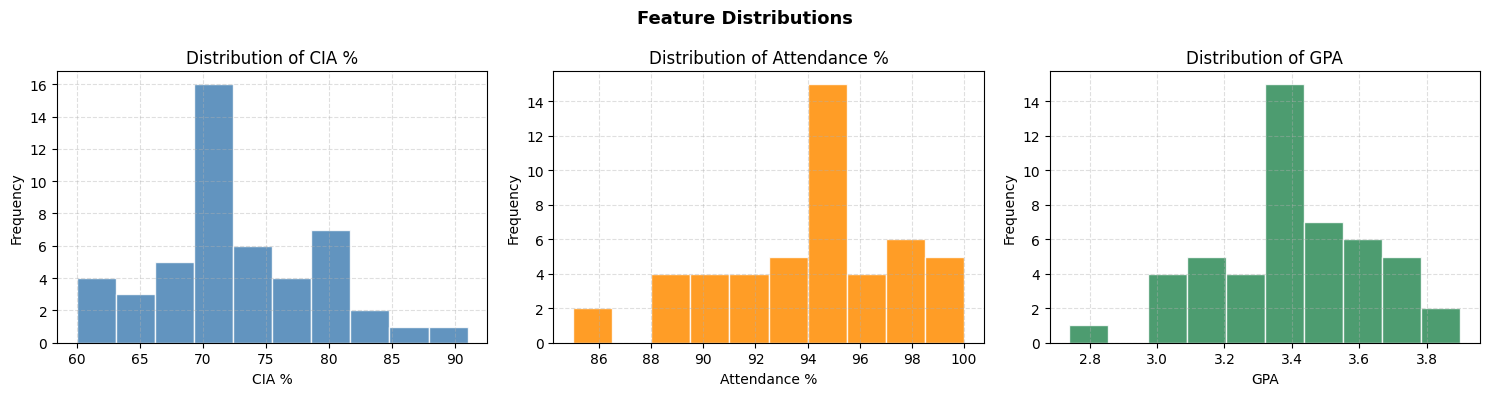

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = {"CIA_pct": "CIA %", "Attendance_pct": "Attendance %", "GPA": "GPA"}
colors = ["steelblue", "darkorange", "seagreen"]

for ax, (col, label), color in zip(axes, cols.items(), colors):
    ax.hist(df[col], bins=10, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribution of {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

<b>The Cia% values lies from 60 to 90 with with maximum number between 70 to 73</b><br>
<b>Attendance lies from 85 to 100 with maximum between 94 to 95</b><br>
<b>GPA values lies from 2.8 to 4 with maximum concetration from 3.3 to 3.4</b>

<b>Saveing to cleaned dataset</b>

In [80]:
df.to_csv("Student_Survey_Cleaned.csv", index=False)

<b>Part B: Simple Linear Regression using Scikit-learn</b><br>
Perform the following:
<br>Split the dataset into training and testing sets
<br>Train the model using LinearRegression from Scikit learn
<br>Obtain:
<br>Slope
<br>Intercept
<br>Predict output values using the trained mod


In [81]:
df_clean = pd.read_csv("Student_Survey_Cleaned.csv")

In [82]:
X1 = df_clean[["CIA_pct"]]
y1 = df_clean["GPA"]  

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)
print(f"\nTraining samples : {len(X1_train)}")
print(f"Testing  samples : {len(X1_test)}")

model1 = LinearRegression()
model1.fit(X1_train, y1_train)

print(f"\nSlope: {model1.coef_[0]:.4f}")
print(f"Intercept: {model1.intercept_:.4f}")
print(f"Equation: GPA = {model1.coef_[0]:.4f} * CIA_pct + {model1.intercept_:.4f}")


Training samples : 39
Testing  samples : 10

Slope: 0.0128
Intercept: 2.4834
Equation: GPA = 0.0128 * CIA_pct + 2.4834


In [83]:
y1_pred = model1.predict(X1_test)
 
print("\nPredicted vs Actual GPA (first 10 test samples):")
comparison1 = pd.DataFrame({
    "CIA_pct": X1_test["CIA_pct"].values,
    "Actual GPA": y1_test.values,
    "Predicted GPA": np.round(y1_pred, 4)
})
print(comparison1.to_string(index=False))


Predicted vs Actual GPA (first 10 test samples):
 CIA_pct  Actual GPA  Predicted GPA
    70.0        3.49         3.3794
    70.0        3.69         3.3794
    66.0        2.74         3.3282
    75.0        3.66         3.4434
    64.0        3.11         3.3026
    71.0        3.33         3.3922
    70.0        3.00         3.3794
    70.0        3.40         3.3794
    80.0        3.60         3.5074
    70.0        3.34         3.3794


In [84]:
mse1  = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
r2_1  = r2_score(y1_test, y1_pred)
print(f"\nMSE: {mse1:.4f}")
print(f"RMSE: {rmse1:.4f}")
print(f"R2: {r2_1:.4f}")


MSE: 0.0697
RMSE: 0.2640
R2: 0.1771


There is a weak positive relation between CIA and GPA which is 17.7%.<br>
RMSE of 0.26 suggest that model GPA prediction deviate by 0.26.<br>
MSE of 0.06 suggest that error are there and model is not accurate.

<b>Experiment 2</b>

In [85]:
X2 = df_clean[["Attendance_pct"]]  
y2 = df_clean["GPA"]               

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {len(X2_train)}")
print(f"Testing  samples: {len(X2_test)}")

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print(f"\nSlope: {model2.coef_[0]:.4f}")
print(f"Intercept: {model2.intercept_:.4f}")
print(f"Equation: GPA = {model2.coef_[0]:.4f} * Attendance_pct + {model2.intercept_:.4f}")


Training samples: 39
Testing  samples: 10

Slope: 0.0244
Intercept: 1.1407
Equation: GPA = 0.0244 * Attendance_pct + 1.1407


In [86]:
y2_pred = model2.predict(X2_test)
 
print("\nPredicted vs Actual GPA (first 10 test samples):")
comparison2 = pd.DataFrame({
    "Attendance_pct": X2_test["Attendance_pct"].values,
    "Actual GPA": y2_test.values,
    "Predicted GPA": np.round(y2_pred, 4)
})
print(comparison2.to_string(index=False))
 
mse2  = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
r2_2  = r2_score(y2_test, y2_pred)
print(f"\nMSE: {mse2:.4f}")
print(f"RMSE: {rmse2:.4f}")
print(f"R2: {r2_2:.4f}")


Predicted vs Actual GPA (first 10 test samples):
 Attendance_pct  Actual GPA  Predicted GPA
          100.0        3.49         3.5816
           97.0        3.69         3.5084
           90.0        2.74         3.3375
           95.0        3.66         3.4596
          100.0        3.11         3.5816
           99.0        3.33         3.5572
           93.0        3.00         3.4108
           96.0        3.40         3.4840
           95.0        3.60         3.4596
           95.0        3.34         3.4596

MSE: 0.0922
RMSE: 0.3037
R2: -0.0891


There is a weak negative relation between Attendance and GPA which is -8.9%.<br>
RMSE of 0.26 suggest that model GPA prediction deviate by 0.30.<br>
MSE of 0.09 suggest that error are there and model is not accurate.

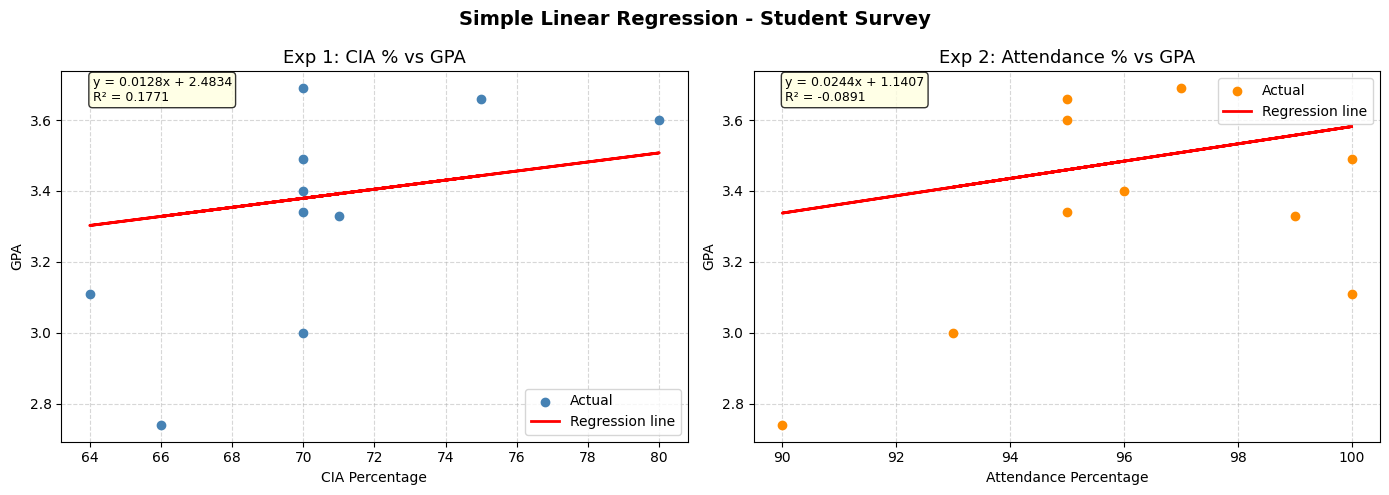

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(X1_test, y1_test, color="steelblue", label="Actual", zorder=3)
ax1.plot(X1_test, y1_pred, color="red", linewidth=2, label="Regression line")
ax1.set_title("Exp 1: CIA % vs GPA", fontsize=13)
ax1.set_xlabel("CIA Percentage")
ax1.set_ylabel("GPA")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.text(0.05, 0.92,
         f"y = {model1.coef_[0]:.4f}x + {model1.intercept_:.4f}\nR² = {r2_1:.4f}",
         transform=ax1.transAxes, fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

ax2 = axes[1]
ax2.scatter(X2_test, y2_test, color="darkorange", label="Actual", zorder=3)
ax2.plot(X2_test, y2_pred, color="red", linewidth=2, label="Regression line")
ax2.set_title("Exp 2: Attendance % vs GPA", fontsize=13)
ax2.set_xlabel("Attendance Percentage")
ax2.set_ylabel("GPA")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.text(0.05, 0.92,
         f"y = {model2.coef_[0]:.4f}x + {model2.intercept_:.4f}\nR² = {r2_2:.4f}",
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
 
plt.suptitle("Simple Linear Regression - Student Survey", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<b>Part C: Manual Computation using Ordinary Least Squares (OLS)</b>
<br>Using the same dataset, manually compute the regression line using the OLS formulas given below.
<br><b>Manual Regression Equation</b>
<br>Construct the regression equation manually using the computed slope and intercept values.
<br><b>Comparison Task</b>
<br>Compare the following:
<br>Predictions from Scikit learn
<br>Predictions from manually computed OLS equation
<br>Difference between both outputs
<br>Provide observations regarding whether both methods produce similar results


In [88]:
def ols_manual(x, y):
    x, y = x.values, y.values
    b1 = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
    return b1, y.mean() - b1 * x.mean()

def run_experiment(exp_num, x_col, y_col, df):
    X_train, X_test, y_train, y_test = train_test_split(
        df[[x_col]], df[y_col], test_size=0.2, random_state=42
    )

    sk = LinearRegression().fit(X_train, y_train)
    y_pred_sk = sk.predict(X_test)

    m_slope, m_intercept = ols_manual(X_train[x_col], y_train)
    y_pred_man = m_slope * X_test[x_col].values + m_intercept

    xv, yv = X_train[x_col].values, y_train.values
    xm, ym = xv.mean(), yv.mean()
    print(f"x'={xm:.4f}, y`={ym:.4f}")
    print(f"sum(xi-x`)(yi-y`) = {np.sum((xv-xm)*(yv-ym)):.4f}")
    print(f"sum(xi-x`)2 = {np.sum((xv-xm)**2):.4f}")

    print(f"\nScikit-learn: {y_col} = {sk.coef_[0]:.6f}*{x_col} + {sk.intercept_:.6f}")
    print(f"Manual OLS: {y_col} = {m_slope:.6f}*{x_col} + {m_intercept:.6f}")

    diff = np.abs(y_pred_sk - y_pred_man)
    print(f"\nMax |diff| = {diff.max():.2e} | Mean |diff| = {diff.mean():.2e}")

    return {
        "x_col": x_col, "y_col": y_col,
        "X_test": X_test, "y_test": y_test,
        "sk_slope": sk.coef_[0], "sk_intercept": sk.intercept_,
        "man_slope": m_slope, "man_intercept": m_intercept,
        "y_pred_sk": y_pred_sk, "y_pred_manual": y_pred_man, "diff": diff
    }

In [89]:
r1 = run_experiment(1,"CIA_pct","GPA",df_clean)
print("\n")
r2 = run_experiment(2,"Attendance_pct","GPA",df_clean)

x'=73.3956, y`=3.4228
sum(xi-x`)(yi-y`) = 21.9668
sum(xi-x`)2 = 1716.1978

Scikit-learn: GPA = 0.012800*CIA_pct + 2.483380
Manual OLS: GPA = 0.012800*CIA_pct + 2.483380

Max |diff| = 4.44e-16 | Mean |diff| = 1.33e-16


x'=93.4933, y`=3.4228
sum(xi-x`)(yi-y`) = 12.3985
sum(xi-x`)2 = 507.9299

Scikit-learn: GPA = 0.024410*Attendance_pct + 1.140655
Manual OLS: GPA = 0.024410*Attendance_pct + 1.140655

Max |diff| = 4.44e-16 | Mean |diff| = 4.44e-17


<b>The manual and sickit learn shows the same results as both use the same forulas so the difference is negligible.</b>

<b>Comparision Task</b>

In [90]:
print(
    """Experiment 1 — CIA % vs GPA:
    Both methods produced identical regression equations:

    Scikit-learn: GPA = 0.012800 * CIA_pct + 2.483380
    Manual OLS: GPA = 0.012800 * CIA_pct + 2.483380

    The prediction values are exactly the same for all 10 test samples. 
"""
)
print()
print(
    """Experiment 2 — Attendance % vs GPA:
    Again both methods produced identical regression equations:

    Scikit-learn: GPA = 0.024410 * Attendance_pct + 1.140655
    Manual OLS: GPA = 0.024410 * Attendance_pct + 1.140655

    All 10 predictions match perfectly. 
    """
)

Experiment 1 — CIA % vs GPA:
    Both methods produced identical regression equations:

    Scikit-learn: GPA = 0.012800 * CIA_pct + 2.483380
    Manual OLS: GPA = 0.012800 * CIA_pct + 2.483380

    The prediction values are exactly the same for all 10 test samples. 


Experiment 2 — Attendance % vs GPA:
    Again both methods produced identical regression equations:

    Scikit-learn: GPA = 0.024410 * Attendance_pct + 1.140655
    Manual OLS: GPA = 0.024410 * Attendance_pct + 1.140655

    All 10 predictions match perfectly. 
    


<b>Parameter Saving Task</b>
<br>Save the parameters learned by the model using Pickle.
<br>The following parameters must be saved:
<br>Slope
<br>Intercept
<br>Suggested file name:
<br>linear_regression_weights.pkl
<br><b>Demonstrate:</b>
<br>Saving parameters into Pickle file
<br>Loading the Pickle file
<br>Using loaded parameters for prediction


In [91]:
trained = {
    "Experiment 1": {
        "x_col": r1["x_col"],
        "slope": r1["sk_slope"],
        "intercept": r1["sk_intercept"],
        "X_test": r1["X_test"],
        "y_test": r1["y_test"],
    },
    "Experiment 2": {
        "x_col": r2["x_col"],
        "slope": r2["sk_slope"],
        "intercept": r2["sk_intercept"],
        "X_test": r2["X_test"],
        "y_test": r2["y_test"],
    },
}

parameters_to_save = {
    exp_name: {
        "slope": info["slope"],
        "intercept": info["intercept"],
        "x_col": info["x_col"],
    }
    for exp_name, info in trained.items()
}

pickle_file = "linear_regression_weights.pkl"

with open(pickle_file, "wb") as f:
    pickle.dump(parameters_to_save, f)

print(f"\nParameters saved successfully to '{pickle_file}'\n")
print("Parameters saved:")
for exp_name, params in parameters_to_save.items():
    print(f"\n[{exp_name}]  ({params['x_col']} - GPA)")
    print(f"Slope: {params['slope']:.6f}")
    print(f"Intercept: {params['intercept']:.6f}")


Parameters saved successfully to 'linear_regression_weights.pkl'

Parameters saved:

[Experiment 1]  (CIA_pct - GPA)
Slope: 0.012800
Intercept: 2.483380

[Experiment 2]  (Attendance_pct - GPA)
Slope: 0.024410
Intercept: 1.140655


In [92]:
with open(pickle_file, "rb") as f:
    loaded_params = pickle.load(f)

print(f"\nParameters loaded successfully from '{pickle_file}'\n")
print("Loaded Parameters:")
for exp_name, params in loaded_params.items():
    print(f"\n[{exp_name}] ({params['x_col']} - GPA)")
    print(f"Slope: {params['slope']:.6f}")
    print(f"Intercept: {params['intercept']:.6f}")


Parameters loaded successfully from 'linear_regression_weights.pkl'

Loaded Parameters:

[Experiment 1] (CIA_pct - GPA)
Slope: 0.012800
Intercept: 2.483380

[Experiment 2] (Attendance_pct - GPA)
Slope: 0.024410
Intercept: 1.140655


In [93]:
for exp_name, params in loaded_params.items():
    b1 = params["slope"]
    b0 = params["intercept"]
    col = params["x_col"]

    X_test = trained[exp_name]["X_test"]
    y_test = trained[exp_name]["y_test"]

    y_pred = b1 * X_test[col].values + b0

    print(f"\n[{exp_name}] {col} - GPA")
    print(f"Equation: GPA = {b1:.6f} * {col} + {b0:.6f}")
    print()

    result_df = pd.DataFrame({
        col: X_test[col].values,
        "Actual GPA": np.round(y_test.values, 4),
        "Predicted GPA": np.round(y_pred, 4),
        "Error (Actual - Pred)": np.round(y_test.values - y_pred, 4),
    })
    print(result_df.to_string(index=False))


[Experiment 1] CIA_pct - GPA
Equation: GPA = 0.012800 * CIA_pct + 2.483380

 CIA_pct  Actual GPA  Predicted GPA  Error (Actual - Pred)
    70.0        3.49         3.3794                 0.1106
    70.0        3.69         3.3794                 0.3106
    66.0        2.74         3.3282                -0.5882
    75.0        3.66         3.4434                 0.2166
    64.0        3.11         3.3026                -0.1926
    71.0        3.33         3.3922                -0.0622
    70.0        3.00         3.3794                -0.3794
    70.0        3.40         3.3794                 0.0206
    80.0        3.60         3.5074                 0.0926
    70.0        3.34         3.3794                -0.0394

[Experiment 2] Attendance_pct - GPA
Equation: GPA = 0.024410 * Attendance_pct + 1.140655

 Attendance_pct  Actual GPA  Predicted GPA  Error (Actual - Pred)
          100.0        3.49         3.5816                -0.0916
           97.0        3.69         3.5084         